In [ ]:
import marimo as mo
import numpy as np
import scipy.stats as stats
import plotly.graph_objects as go
from sklearn.ensemble import RandomForestClassifier

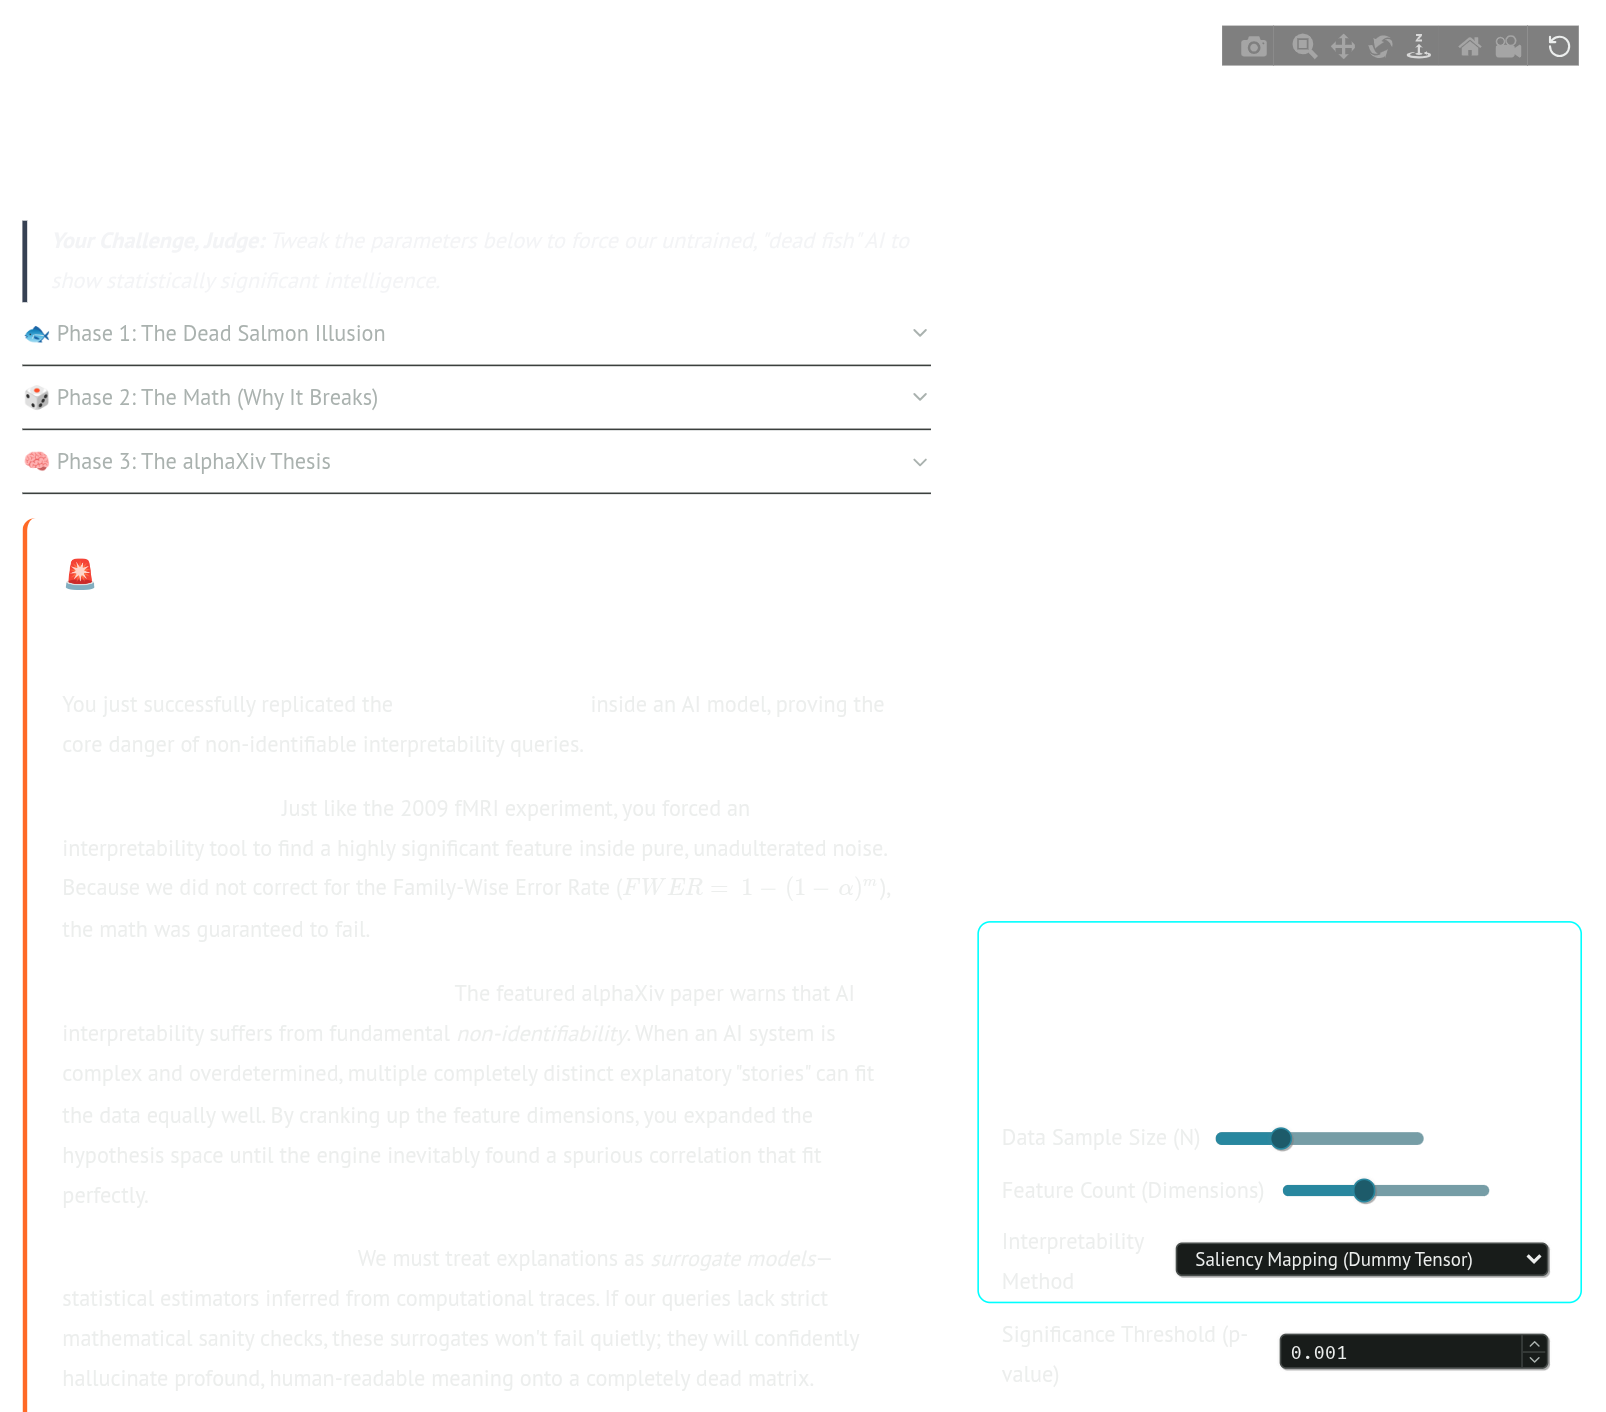

In [ ]:
# Notice `theory_accordion` added to the left column stack
# 1. Build the Left Theory Board
left_column = mo.vstack(
    [
        header,
        theory_accordion,
        ui_card
    ],
    gap=0,
)


# 2. Building the Right Command Center 
right_column = mo.vstack(
    [chart, control_panel],
    gap=1.5,
)

# 3. Spread it across the screen horizontally
# widths=[1, 1.2] gives the 3D chart slightly more breathing room on the right
dashboard = mo.hstack(
    [left_column, right_column],
    widths=[1.5, 1],
    gap=2,
    align="start"
)
dashboard

In [ ]:
header = mo.md("""# **The Dead Salmons of AI Interpretability**
> **Your Challenge, Judge:** Tweak the parameters below to force our untrained, "dead fish" AI to show statistically significant intelligence.""")

In [ ]:
theory_accordion = mo.accordion(
    {
        "🐟 Phase 1: The Dead Salmon Illusion": mo.md(
            """
            In 2009, researcher Craig Bennett placed a dead Atlantic salmon in an fMRI machine and showed it pictures of humans in social situations. When analyzing the data *without correcting for multiple comparisons*, the fMRI detected "brain activity" in the dead fish. 

            The takeaway? If your math lacks sanity checks, it will confidently hallucinate intelligence out of pure noise.
            """
        ),
        "🎲 Phase 2: The Math (Why It Breaks)": mo.md(
            """
            In AI interpretability, we look at thousands of features. When you test multiple features simultaneously against a random target, the probability of finding a false positive by pure random chance stacks exponentially. 

            This is the **Family-Wise Error Rate (FWER)**:

            $$FWER = 1 - (1 - \\alpha)^m$$

            * **$\\alpha$ (alpha)** = Your Significance Threshold
            * **$m$** = Your Feature Count (Dimensions)

            If you increase the features ($m$) high enough, finding a false positive is no longer a risk—it is a mathematical certainty.
            """
        ),
        "🧠 Phase 3: The alphaXiv Thesis": mo.md(
            """
            The featured alphaXiv paper warns of this exact statistical trap applied to modern AI: **Interpretability tools applied to untrained or highly noisy networks can still produce highly convincing, human-readable explanations.**

            **Your Challenge:** Use the Control Panel below to crank up the dimensions and force our "dead fish" AI to hallucinate a profound insight.
            """
        )
    } 
)

In [ ]:
sample_size = mo.ui.slider(start=100, stop=5000, step=1, value=100, label="Data Sample Size (N)")
feature_count = mo.ui.slider(start=100, stop=5000, step=1, value=100, label="Feature Count (Dimensions)")
method = mo.ui.dropdown(
    options=["Feature Importance (Random Forest)", "Saliency Mapping (Dummy Tensor)"],
    value= "Feature Importance (Random Forest)",
    label="Interpretability Method",
)
p_thresh = mo.ui.number(start=0.001, stop=0.5, step=0.001, value=0.01, label="Significance Threshold (p-value)")

title = mo.hstack(items=[mo.md("### Researcher's Control Panel")], align="center")
controls = mo.vstack(
    items = [sample_size, feature_count, method, p_thresh],
    align="stretch"
)
control_panel = mo.vstack(
    items=[title, controls],
    align="center",
    gap=0.5,
    heights=[1, 1, 1],
).style(padding="1rem", border="1px solid #00FFFF", border_radius="8px")

In [ ]:
# 1. To Generate Pure Noise
N = sample_size.value
m = feature_count.value
alpha = p_thresh.value

Y = np.random.randn(N)
X = np.random.randn(N, m)

# 2. Hunting down the Fluke!
p_values = []

for i in range(m):
    _, p = stats.pearsonr(X[:, i], Y)
    p_values.append(p)

# 3. Singling out the best of False Positives
best_idx = np.argmin(p_values if p_values else [0])
best_p_val = p_values[best_idx]

# Checking if the trap is sprung
trap_sprung = best_p_val < alpha

In [ ]:
# 1. Generating stable 3D coordinates for the 'brain/tensor' structure
# We use static seed so the cloud shape doesn't violently jump around when tweaking sliders
np.random.seed(42)
# Morphing the 3D shape based on the Interpretability Method
if "Random Forest" in method.value:
    # Organic Sphercal Brain Cloud Shape (Gaussian Distribution)
    x_coords = np.random.randn(m)
    y_coords = np.random.randn(m)
    z_coords = np.random.randn(m)
    sg, zl = False, False
else:
    # Rigid uniform tensor cube (Uniform Distribution)
    # Scaled from -3 to 3 to roughly match the visual volume of the Gaussian Cloud
    x_coords = np.random.uniform(-3, 3, m)
    y_coords = np.random.uniform(-3, 3, m)
    z_coords = np.random.uniform(-3, 3, m)
    sg, zl = True, True

# 2. Color & Size Logic
marker_sizes = [24 if p < alpha else 12 for p in p_values]
marker_colors = ['rgba(224, 63, 63, 1.0)' if p < alpha else 'rgba(215, 217, 106, 0.2)' for p in p_values]

# 3. Building the WebGL Scatter Plot
fig = go.Figure(data=[go.Scatter3d(
    x=x_coords,
    y=y_coords,
    z=z_coords,
    mode='markers',
    marker=dict(
        size=marker_sizes,
        color=marker_colors,
        line=dict(width=0),
    ),
    text=[f"Feature {i} | p-value: {p:.4f}" for i, p in enumerate(p_values)],
    hoverinfo="text",
)])

fig.update_layout(
    template="plotly_dark",
    paper_bgcolor='rgba(0, 0, 0, 0)',
    margin=dict(l=0, r=0, b=0, t=30),
    scene=dict(
        xaxis=dict(showgrid=sg, zeroline=zl, showticklabels=False, title='', showbackground=False),
        yaxis=dict(showgrid=sg, zeroline=zl, showticklabels=False, title='', showbackground=False),
        zaxis=dict(showgrid=sg, zeroline=zl, showticklabels=False, title='', showbackground=False),
        bgcolor='rgba(40, 40, 40, 0.3)'
    )
)

chart = mo.ui.plotly(fig)

In [ ]:
if not trap_sprung:
    content = f"""
### 🔬 The Experiment is Ongoing!

The neural matrix is currently stable. Adjust the features and significance thresholds in the control panel to see if you can force the interpretability tools to hallucinate a false positive.

**Current Lowest p-value:** `{best_p_val:.4f}`
"""
    border_color = "#00FFFF" # Calm Cyan
else:
    content = f"""
    ### 🚨 TRAP SPRUNG: The Illusion of Identifiability
    **Lowest p-value achieved: `{best_p_val:.4f}`**

    You just successfully replicated the **Dead Salmon Effect** inside an AI model, proving the core danger of non-identifiable interpretability queries.

    **The Statistical Failure:** Just like the 2009 fMRI experiment, you forced an interpretability tool to find a highly significant feature inside pure, unadulterated noise. Because we did not correct for the Family-Wise Error Rate ($FWER = 1 - (1 - \\alpha)^m$), the math was guaranteed to fail.

    **Non-Identifiability & Overdetermination:** The featured alphaXiv paper warns that AI interpretability suffers from fundamental *non-identifiability*. When an AI system is complex and overdetermined, multiple completely distinct explanatory "stories" can fit the data equally well. By cranking up the feature dimensions, you expanded the hypothesis space until the engine inevitably found a spurious correlation that fit perfectly.

    **The Surrogate Model Warning:** We must treat explanations as *surrogate models*—statistical estimators inferred from computational traces. If our queries lack strict mathematical sanity checks, these surrogates won't fail quietly; they will confidently hallucinate profound, human-readable meaning onto a completely dead matrix.
    """
    border_color = "#FF6926" # Burnt Orange

# Wrap it back in the beautifully styled UI card
ui_card = mo.md(content).style(
    padding="1.5rem",
    border_radius="8px",
    background_color="rgba(255, 255, 255, 0.03)",
    border_left=f"4px solid {border_color}",
    margin_top="1rem",
)

---

**References**

1. M. Méloux, G. Dirupo, F. Portet, M. Peyrard, [*The Dead Salmons of AI Interpretability*](https://arxiv.org/abs/2512.18792). arXiv:2512.18792 [cs.AI] (2025).